In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier

In [2]:
import joblib
import warnings
import sys

=============================================================================<br>
SETTINGS & CONFIGURATION<br>
=============================================================================

In [3]:
warnings.simplefilter(action='ignore')
pd.options.mode.chained_assignment = None

In [4]:
print(" [SYSTEM] CS:GO PREDICTOR V13 (SCIENTIFIC EDITION) STARTING...")

 [SYSTEM] CS:GO PREDICTOR V13 (SCIENTIFIC EDITION) STARTING...


=============================================================================<br>
1. DATA LOADING<br>
=============================================================================

In [5]:
try:
    df_results = pd.read_csv('results.csv')
    df_players = pd.read_csv('players.csv')
    df_eco = pd.read_csv('economy.csv', low_memory=False)
except:
    print("ERROR: csv files not found! Please check your directory.")
    sys.exit()

Function to clean column names (remove spaces, lowercase)

In [6]:
def clean_col_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

In [7]:
df_results = clean_col_names(df_results)
df_players = clean_col_names(df_players)
df_eco = clean_col_names(df_eco)

Standardize map column name

In [8]:
map_col = '_map' if '_map' in df_results.columns else 'map'
df_results.rename(columns={map_col: '_map'}, inplace=True)

Drop duplicate or unnecessary columns from economy dataframe to avoid merge conflicts

In [9]:
cols_drop = ['date', 'team_1', 'team_2', '_map', 'event_id', 'best_of']
for c in cols_drop:
    if c in df_eco.columns: df_eco.drop(columns=[c], inplace=True)

Convert date columns to datetime objects

In [10]:
df_results['date'] = pd.to_datetime(df_results['date'])
df_players['date'] = pd.to_datetime(df_players['date'])
if 'team_name' not in df_players.columns and 'team' in df_players.columns:
    df_players.rename(columns={'team': 'team_name'}, inplace=True)

Function to normalize team names (handling case sensitivity)

In [11]:
def normalize_names(series):
    return series.str.lower().str.strip().str.replace(' ', '_')

In [12]:
df_results['team_1'] = normalize_names(df_results['team_1'])
df_results['team_2'] = normalize_names(df_results['team_2'])
df_players['team_name'] = normalize_names(df_players['team_name'])

=============================================================================<br>
2. FEATURE ENGINEERING<br>
=============================================================================

In [13]:
print(" [PROCESS] Processing data & engineering features...")

 [PROCESS] Processing data & engineering features...


--- Pistol Round Analysis ---<br>
Merging economy data to determine who won pistol rounds (Round 1 and 16)

In [14]:
df_eco_m = pd.merge(df_eco, df_results[['match_id', 'date', 'team_1', 'team_2']], on='match_id', how='left')
df_eco_m.dropna(subset=['date'], inplace=True)
p_data = []
for i, r in df_eco_m.iterrows():
    try:
        # Check 1st Round Winner
        if pd.notna(r.get('1_winner')):
            w = int(float(r['1_winner']))
            p_data.extend([{'date': r['date'], 'team': r['team_1'], 'pw': 1 if w == 1 else 0},
                           {'date': r['date'], 'team': r['team_2'], 'pw': 1 if w == 2 else 0}])
        # Check 16th Round Winner
        if pd.notna(r.get('16_winner')):
            w = int(float(r['16_winner']))
            p_data.extend([{'date': r['date'], 'team': r['team_1'], 'pw': 1 if w == 1 else 0},
                           {'date': r['date'], 'team': r['team_2'], 'pw': 1 if w == 2 else 0}])
    except:
        continue

In [15]:
if p_data:
    df_p = pd.DataFrame(p_data).sort_values(by=['team', 'date'])
    # Calculate rolling average of pistol win rate (Last 20 matches)
    df_p['p_wr'] = df_p.groupby('team')['pw'].transform(lambda x: x.rolling(20, min_periods=5).mean().shift(1)).fillna(
        0.5)
    p_stats = df_p.groupby(['date', 'team'])['p_wr'].mean().reset_index()
else:
    p_stats = pd.DataFrame(columns=['date', 'team', 'p_wr'])

--- Rank & ELO Calculation ---

In [16]:
df_results['rank_1'] = pd.to_numeric(df_results['rank_1'], errors='coerce').fillna(300)
df_results['rank_2'] = pd.to_numeric(df_results['rank_2'], errors='coerce').fillna(300)

In [17]:
tr = {}
df_results.sort_values(by='date', inplace=True)

Custom ELO Algorithm

In [18]:
def elo(t1, t2, w, k=30):
    r1, r2 = tr.get(t1, 1500), tr.get(t2, 1500)
    e1 = 1 / (1 + 10 ** ((r2 - r1) / 400));
    e2 = 1 / (1 + 10 ** ((r1 - r2) / 400))
    tr[t1], tr[t2] = r1 + k * ((1 if w == 1 else 0) - e1), r2 + k * ((1 if w == 2 else 0) - e2)
    return r1, r2

In [19]:
el = [elo(r['team_1'], r['team_2'], r['match_winner']) for i, r in df_results.iterrows()]
df_results['t1_elo'] = [x[0] for x in el];
df_results['t2_elo'] = [x[1] for x in el]

--- Team Momentum & Player Impact Stats ---

In [20]:
t1r = df_results[['date', 'team_1', 'match_winner']].rename(columns={'team_1': 'team'});
t1r['w'] = (t1r['match_winner'] == 1).astype(int)
t2r = df_results[['date', 'team_2', 'match_winner']].rename(columns={'team_2': 'team'});
t2r['w'] = (t2r['match_winner'] == 2).astype(int)
th = pd.concat([t1r, t2r]).sort_values(by=['team', 'date'])
# Rolling Win Rate (Last 5 games)
th['wr'] = th.groupby('team')['w'].transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1)).fillna(0.5)
t_wr = th.groupby(['date', 'team'])['wr'].mean().reset_index()

Player Impact Rating Calculation

In [21]:
df_players.fillna(0, inplace=True)
df_players['imp'] = (df_players['kills'] * 1.2 + df_players['assists'] * 0.3 + df_players['fkdiff'] * 0.7 + df_players[
    'kast'] * 0.05 + df_players['adr'] * 0.01 - df_players['deaths'] * 0.5)
df_players.sort_values(by=['player_name', 'date'], inplace=True)
# Rolling average of player impact
df_players['avg'] = df_players.groupby('player_name')['imp'].transform(
    lambda x: x.rolling(10, min_periods=1).mean().shift(1)).fillna(0)
t_stats = df_players.groupby(['match_id', 'team_name'])['avg'].mean().reset_index()

--- Data Merging ---

In [22]:
print(" [MERGE] Merging datasets...")
df = pd.merge(df_results, t_stats, left_on=['match_id', 'team_1'], right_on=['match_id', 'team_name'],
              how='left').rename(columns={'avg': 't1_p'}).drop(columns=['team_name'])
df = pd.merge(df, t_stats, left_on=['match_id', 'team_2'], right_on=['match_id', 'team_name'], how='left').rename(
    columns={'avg': 't2_p'}).drop(columns=['team_name'])
df = pd.merge(df, t_wr, left_on=['date', 'team_1'], right_on=['date', 'team'], how='left').rename(
    columns={'wr': 't1_wr'}).drop(columns=['team'])
df = pd.merge(df, t_wr, left_on=['date', 'team_2'], right_on=['date', 'team'], how='left').rename(
    columns={'wr': 't2_wr'}).drop(columns=['team'])

 [MERGE] Merging datasets...


In [23]:
if not p_stats.empty:
    df = pd.merge(df, p_stats, left_on=['date', 'team_1'], right_on=['date', 'team'], how='left').rename(
        columns={'p_wr': 't1_pis'}).drop(columns=['team'])
    df = pd.merge(df, p_stats, left_on=['date', 'team_2'], right_on=['date', 'team'], how='left').rename(
        columns={'p_wr': 't2_pis'}).drop(columns=['team'])
else:
    df['t1_pis'] = 0.5;
    df['t2_pis'] = 0.5

In [24]:
df.dropna(subset=['t1_p', 't2_p'], inplace=True)
df.fillna(0.5, inplace=True)


Calculating Differential Features

In [25]:
df['elo_d'] = df['t1_elo'] - df['t2_elo']
df['rank_d'] = df['rank_2'] - df['rank_1']
df['perf_d'] = df['t1_p'] - df['t2_p']
df['wr_d'] = df['t1_wr'] - df['t2_wr']
df['pis_d'] = df['t1_pis'] - df['t2_pis']
df['elo_x_wr'] = df['elo_d'] * df['wr_d']
df['rank_x_perf'] = df['rank_d'] * df['perf_d']

One Hot Encoding for Maps


 🔗 FEATURE CORRELATION MATRIX
+--------+---------+----------+--------+----------+---------+
|        |   elo_d |   rank_d |   wr_d |   perf_d |   pis_d |
|--------+---------+----------+--------+----------+---------|
| elo_d  |    1.00 |     0.53 |   0.50 |     0.32 |    0.11 |
| rank_d |    0.53 |     1.00 |   0.26 |     0.25 |    0.07 |
| wr_d   |    0.50 |     0.26 |   1.00 |     0.27 |    0.17 |
| perf_d |    0.32 |     0.25 |   0.27 |     1.00 |    0.08 |
| pis_d  |    0.11 |     0.07 |   0.17 |     0.08 |    1.00 |
+--------+---------+----------+--------+----------+---------+



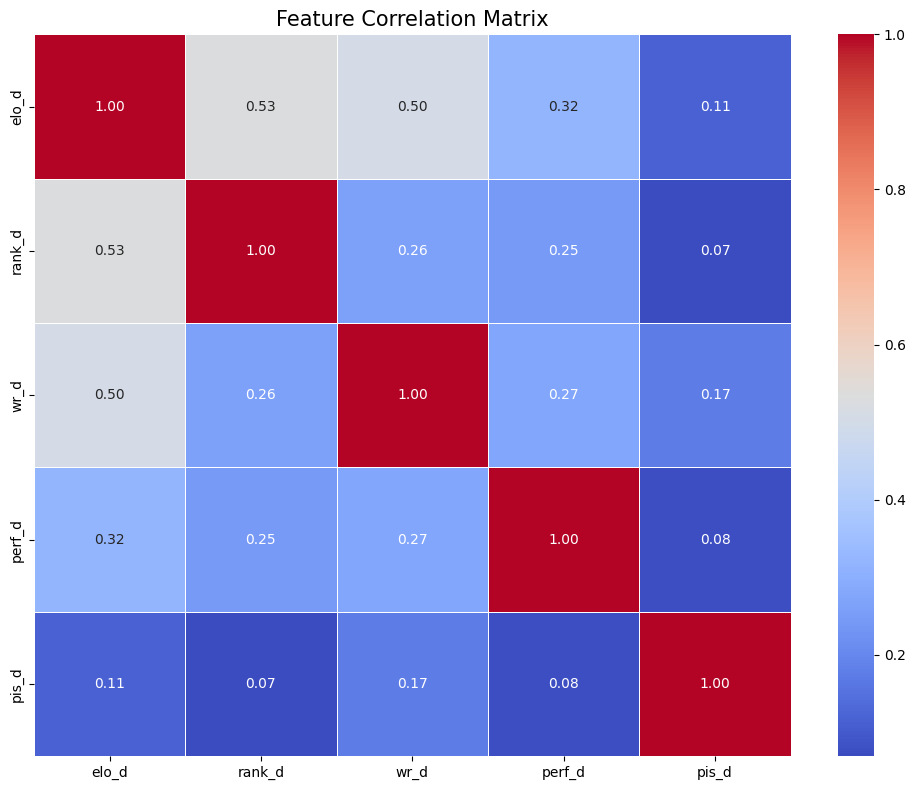

In [26]:
df = pd.get_dummies(df, columns=['_map'], prefix='map')
df.columns = df.columns.str.lower()

corr_cols = ['elo_d', 'rank_d', 'wr_d', 'perf_d', 'pis_d']
corr_matrix = df[corr_cols].corr()

print("\n" + "="*50)
print(" 🔗 FEATURE CORRELATION MATRIX")
print("="*50)
print(tabulate(corr_matrix, headers='keys', tablefmt='psql', floatfmt=".2f"))
print("="*50 + "\n")


plt.figure(figsize=(10, 8))  # Resim boyutu

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=15)
plt.tight_layout()


plt.savefig("correlation_matrix.png", dpi=300)

=============================================================================<br>
3. MODEL TRAINING & BENCHMARKING (V13 - SCIENTIFIC EDITION)<br>
=============================================================================

In [27]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

In [28]:
print(" [FIX] Applying Data Mirroring (Augmentation)...")
# Splitting data by date
train_raw = df[df['date'] < '2019-01-01']
test = df[df['date'] >= '2019-01-01']

 [FIX] Applying Data Mirroring (Augmentation)...


Function to mirror data (T1 vs T2 -> T2 vs T1) to remove positional bias

In [29]:
def mirror_data(data):
    mirrored = data.copy()
    swap_map = {
        't1_elo': 't2_elo', 't2_elo': 't1_elo',
        'rank_1': 'rank_2', 'rank_2': 'rank_1',
        't1_wr': 't2_wr', 't2_wr': 't1_wr',
        't1_p': 't2_p', 't2_p': 't1_p',
        't1_pis': 't2_pis', 't2_pis': 't1_pis'
    }
    mirrored.rename(columns=swap_map, inplace=True)
    diff_cols = ['elo_d', 'rank_d', 'perf_d', 'wr_d', 'pis_d', 'elo_x_wr', 'rank_x_perf']
    for c in diff_cols: mirrored[c] = -mirrored[c]
    mirrored['match_winner'] = mirrored['match_winner'].apply(lambda x: 2 if x == 1 else 1)
    return mirrored

In [30]:
train_mirror = mirror_data(train_raw)
train = pd.concat([train_raw, train_mirror], ignore_index=True)

In [31]:
target = 'match_winner'
y_train = train[target].apply(lambda x: 0 if x == 1 else 1)
y_test = test[target].apply(lambda x: 0 if x == 1 else 1)

Defining Feature Columns

In [32]:
cols = ['t1_elo', 't2_elo', 'elo_d', 'rank_1', 'rank_2', 'rank_d',
        't1_wr', 't2_wr', 'wr_d', 't1_p', 't2_p', 'perf_d',
        't1_pis', 't2_pis', 'pis_d', 'elo_x_wr', 'rank_x_perf']
map_cols = [c for c in df.columns if c.startswith('map_') and 'win' not in c and 'result' not in c]
cols += map_cols

In [33]:
display_maps = sorted([c.replace('map_', '').title() for c in map_cols])

In [34]:
print(f" [TRAIN] Training Multiple Models for Benchmarking...")

 [TRAIN] Training Multiple Models for Benchmarking...


--- 1. MODEL DEFINITIONS ---

In [35]:
models_config = {
    "Logistic Regression": LogisticRegression(solver='saga', max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN (5-Neighbors)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=1000, max_depth=10, max_samples=0.8,
        max_features=0.7, n_jobs=-1, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.01, max_depth=6,
        subsample=0.8, colsample_bytree=0.7, gamma=0.5,
        tree_method='hist', device='cuda', random_state=42, eval_metric='logloss'
        # if no GPU: device='cpu'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.01, max_depth=6,
        device='gpu', random_state=42, verbose=-1
        # if no GPU: device='cpu'
    )
}

In [36]:
trained_models = {}
results = []

--- 2. TRAINING LOOP ---

In [37]:
for name, model in models_config.items():
    print(f" -> Training: {name}...")
    try:
        model.fit(train[cols], y_train)
        preds = model.predict(test[cols])
        

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(test[cols])[:, 1]
            ll = log_loss(y_test, probs)
        else:
            ll = np.nan 

        # METRICS CALCULATION
        results.append({
            "Model": name, 
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1-Score": f1_score(y_test, preds, zero_division=0),
            "Log Loss": ll
        })
        trained_models[name] = model
    except Exception as e:
        print(f"    [ERROR] {name} failed. Reason: {e}")

 -> Training: Logistic Regression...
 -> Training: Naive Bayes...
 -> Training: KNN (5-Neighbors)...
 -> Training: Random Forest...
 -> Training: XGBoost...
 -> Training: LightGBM...


--- 3. VOTING CLASSIFIER (ENSEMBLE) ---

In [38]:
print(" -> Creating: Stacking Model (Hybrid Model)...")
estimators = [
    ('rf', trained_models.get('Random Forest')),
    ('nb', trained_models.get('Naive Bayes')),
    ('lr', trained_models.get('Logistic Regression')),
    ('xgb', trained_models.get('XGBoost')),
    ('lgbm', trained_models.get('LightGBM')),
]
estimators = [e for e in estimators if e[1] is not None]

 -> Creating: Stacking Model (Hybrid Model)...


In [39]:
if estimators:
    stacking_model = StackingClassifier(
        estimators=estimators, 
        final_estimator=LogisticRegression(),
        passthrough=False,
        n_jobs=-1
    )
    stacking_model.fit(train[cols], y_train)
    s_preds = stacking_model.predict(test[cols])
    s_probs = stacking_model.predict_proba(test[cols])[:, 1]
    
    results.append({
        "Model": "Stacking", 
        "Accuracy": accuracy_score(y_test, s_preds),
        "Precision": precision_score(y_test, s_preds, zero_division=0),
        "Recall": recall_score(y_test, s_preds, zero_division=0),
        "F1-Score": f1_score(y_test, s_preds, zero_division=0),
        "Log Loss": log_loss(y_test, s_probs)
    })
    trained_models["Stacking"] = stacking_model

[17:16:49] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.



--- 4. COMPARISON OUTPUT ---

In [40]:
df_benchmark = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)


 📊 MODEL COMPARISON RESULTS (SCIENTIFIC)
              Model Accuracy Precision Recall F1-Score Log Loss
           Stacking   77.90%    76.79% 73.51%   75.11%   0.4622
            XGBoost   77.86%    76.66% 73.60%   75.10%   0.4541
           LightGBM   77.84%    76.61% 73.63%   75.09%   0.4543
      Random Forest   76.28%    74.51% 72.54%   73.51%   0.4781
        Naive Bayes   72.49%    70.03% 68.80%   69.41%   0.7469
Logistic Regression   69.06%    67.19% 62.15%   64.57%   0.5884
  KNN (5-Neighbors)   63.43%    60.12% 57.62%   58.84%   2.6691



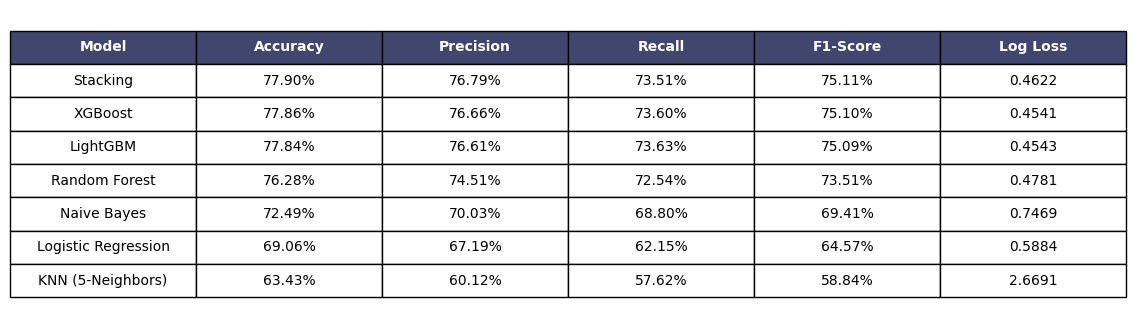

In [41]:
print("\n" + "=" * 100)
print(" 📊 MODEL COMPARISON RESULTS (SCIENTIFIC)")
print("=" * 100)
print(df_benchmark[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss']].to_string(index=False, formatters={
    'Accuracy': '{:.2%}'.format,
    'Precision': '{:.2%}'.format,
    'Recall': '{:.2%}'.format,
    'F1-Score': '{:.2%}'.format,
    'Log Loss': '{:.4f}'.format
}))
print("=" * 100 + "\n")


plot_df = df_benchmark[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss']].copy()

cols_to_pct = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for col in cols_to_pct:
    plot_df[col] = plot_df[col].apply(lambda x: f"{x:.2%}")
plot_df['Log Loss'] = plot_df['Log Loss'].apply(lambda x: f"{x:.4f}")


fig, ax = plt.subplots(figsize=(12, 4)) 
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=plot_df.values, 
                 colLabels=plot_df.columns, 
                 cellLoc='center', 
                 loc='center',
                 colColours=["#40466e"] * len(plot_df.columns)) 

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.get_text().set_color('white')
        cell.get_text().set_weight('bold')

plt.savefig('model_comparasion_table.png', dpi=300, bbox_inches='tight')
plt.show()

AUTO-SELECT BEST MODEL

In [42]:
best_model_name = df_benchmark.iloc[0]['Model']
print(f" [SYSTEM] Best model selected: {best_model_name}")
xgb_model = trained_models[best_model_name]

 [SYSTEM] Best model selected: Stacking


--- 5. VISUALIZATIONS (Confusion Matrix & Calibration) ---

 [GRAPH] Generating Visual Reports... (Checking 3 Plots)

 FEATURE IMPORTANCE ANALYSIS (XGBoost Based)
+----+-----------------+--------------+
|    | Feature         |   Importance |
|----+-----------------+--------------|
|  0 | wr_d            |       0.2390 |
|  1 | t1_wr           |       0.1002 |
|  2 | t2_wr           |       0.0988 |
|  3 | elo_d           |       0.0914 |
|  4 | rank_d          |       0.0877 |
|  5 | t1_elo          |       0.0275 |
|  6 | t2_elo          |       0.0259 |
|  7 | t2_p            |       0.0259 |
|  8 | t1_p            |       0.0254 |
|  9 | rank_2          |       0.0236 |
| 10 | rank_1          |       0.0233 |
| 11 | pis_d           |       0.0213 |
| 12 | perf_d          |       0.0213 |
| 13 | t1_pis          |       0.0209 |
| 14 | t2_pis          |       0.0208 |
| 15 | rank_x_perf     |       0.0208 |
| 16 | elo_x_wr        |       0.0202 |
| 17 | map_nuke        |       0.0164 |
| 18 | map_cobblestone |       0.0155 |
| 19 | map_overpa

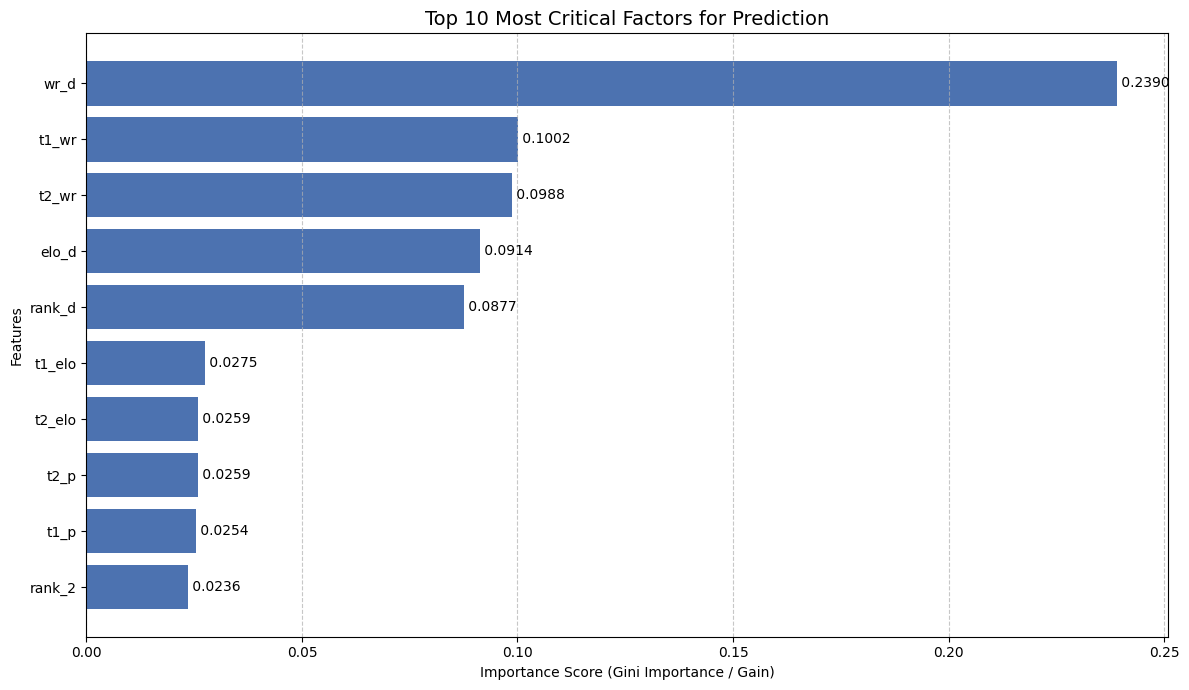

In [54]:
print(" [GRAPH] Generating Visual Reports... (Checking 3 Plots)")

print("\n" + "="*50)
print(" FEATURE IMPORTANCE ANALYSIS (XGBoost Based)")
print("="*50)

if 'XGBoost' in trained_models:
    imp_model = trained_models['XGBoost']

    importances = imp_model.feature_importances_
    feature_names = cols

    # DataFrame oluşturma
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print(tabulate(fi_df, headers='keys', tablefmt='psql', floatfmt=".4f"))

    fi_df.to_csv("feature_importance.csv", index=False)


    plt.figure(figsize=(12, 7))

    top_n = 10
    plt.barh(fi_df['Feature'][:top_n][::-1], fi_df['Importance'][:top_n][::-1], color='#4c72b0')
    
    plt.xlabel("Importance Score (Gini Importance / Gain)")
    plt.ylabel("Features")
    plt.title(f"Top {top_n} Most Critical Factors for Prediction", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    for index, value in enumerate(fi_df['Importance'][:top_n][::-1]):
        plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig("feature_importance_plot.png", dpi=300)
    plt.show() 

else:
    print(" [WARN] XGBoost not found, skipping feature importance.")

print("="*50 + "\n")

Plot 1: Confusion Matrix (Best Model)

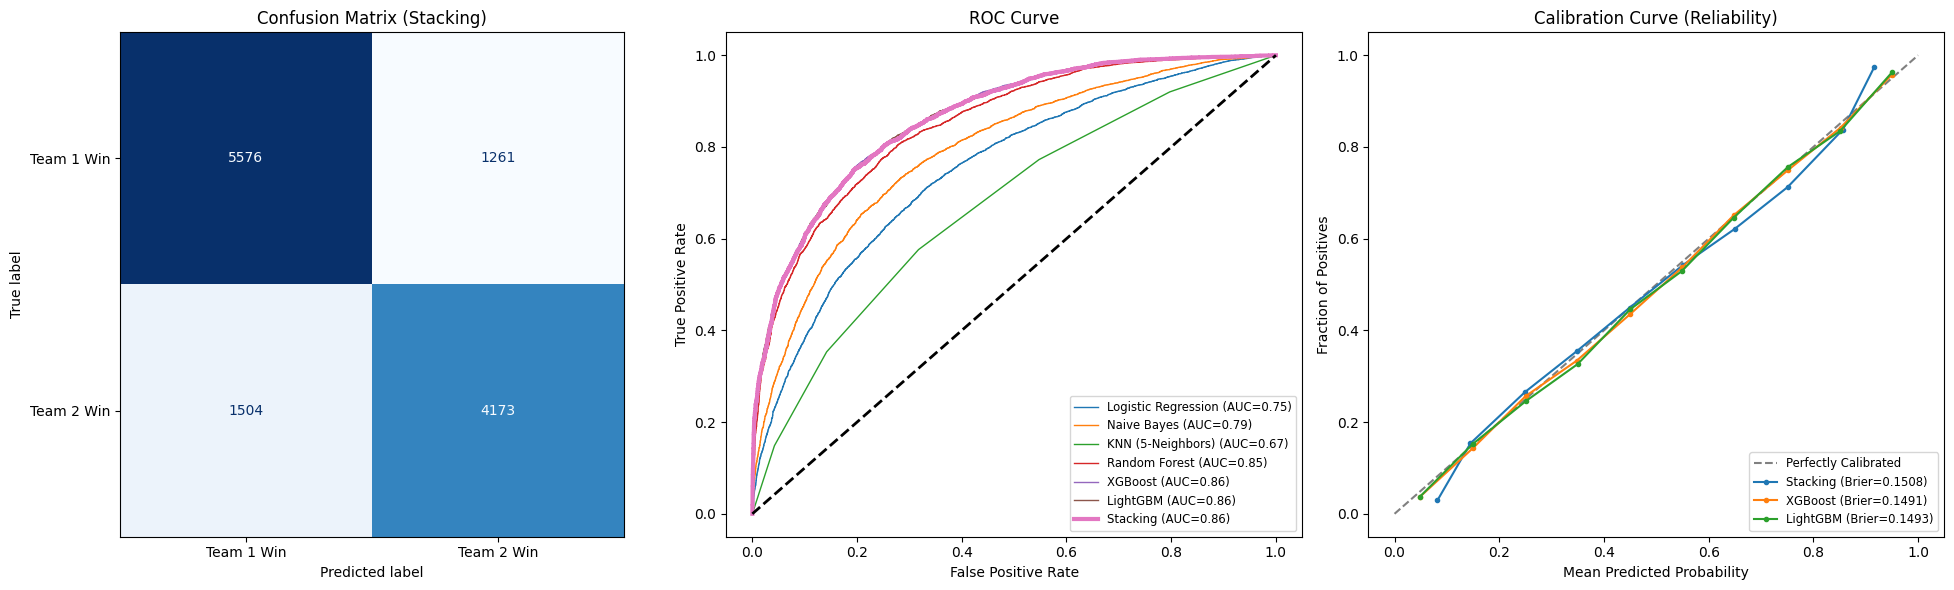

In [52]:
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(1, 3, figsize=(20, 6)) 

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, xgb_model.predict(test[cols]))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Team 1 Win', 'Team 2 Win'])
disp.plot(cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title(f'Confusion Matrix ({best_model_name})')

# --- 2. ROC Curve ---
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        try:
            probs = model.predict_proba(test[cols])[:, 1]
            fpr, tpr, _ = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)
            lw = 3 if name == best_model_name else 1
            ax[1].plot(fpr, tpr, lw=lw, label=f'{name} (AUC={roc_auc:.2f})')
        except: pass
ax[1].plot([0, 1], [0, 1], 'k--', lw=2)
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right", fontsize='small')

# --- 3. Calibration Curve 
top_3_models = df_benchmark.head(3)['Model'].tolist()

ax[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

for name in top_3_models:
    model = trained_models[name]
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(test[cols])[:, 1]
        fop, mpv = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
        
        score = brier_score_loss(y_test, probs)

        ax[2].plot(mpv, fop, marker='.', label=f'{name} (Brier={score:.4f})')

ax[2].set_xlabel('Mean Predicted Probability')
ax[2].set_ylabel('Fraction of Positives')
ax[2].set_title('Calibration Curve (Reliability)')
ax[2].legend(loc="lower right", fontsize='small') 

plt.tight_layout()
plt.savefig('model_performance_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
print(f" [SYSTEM] Saving best model ({best_model_name}) to file...")
joblib.dump(xgb_model, 'csgo_best_model.pkl')

 [SYSTEM] Saving best model (Stacking) to file...


['csgo_best_model.pkl']

=============================================================================<br>
4. TIME TRAVELER MODE (SAFE & INTERACTIVE)<br>
=============================================================================

In [46]:
full_history = df.sort_values(by='date').copy()
all_teams = sorted(list(set(full_history['team_1'].unique()) | set(full_history['team_2'].unique())))

In [47]:
def print_teams_paginated():
    chunk_size = 100
    total = len(all_teams)
    total_pages = (total // chunk_size) + (1 if total % chunk_size > 0 else 0)
    print(f"\n--- TOTAL {total} TEAMS FOUND ({total_pages} Pages) ---\n")
    for i in range(0, total, chunk_size):
        chunk = all_teams[i:i + chunk_size]
        current_page = (i // chunk_size) + 1
        print(", ".join(chunk))
        print(f"\n--- Page {current_page} / {total_pages} ---")
        if i + chunk_size < total:
            choice = input("Press [ENTER] for next page, 'q' to quit list: ")
            if choice.lower() == 'q': break
        else:
            print("--- End of List ---")

In [48]:
def predict_match_timetravel(t1_name, t2_name, map_name):
    t1 = t1_name.strip().lower().replace(' ', '_')
    t2 = t2_name.strip().lower().replace(' ', '_')
    sel_map = map_name.strip().lower()

    # Check if teams exist
    if t1 not in all_teams:
        print(f" [ERROR] Team '{t1_name}' not found. Type 'list' to see all teams.")
        if "navi" in t1: print(" -> Hint: try 'natus_vincere'.")
        return
    if t2 not in all_teams:
        print(f" [ERROR] Team '{t2_name}' not found.")
        if "navi" in t2: print(" -> Hint: try 'natus_vincere'.")
        return

    # LOGIC: Find the LAST MATCH between these two teams
    mask = ((full_history['team_1'] == t1) & (full_history['team_2'] == t2)) | \
           ((full_history['team_1'] == t2) & (full_history['team_2'] == t1))
    matches = full_history[mask]
    if matches.empty:
        print(f" [!] These teams have never met in the dataset.")

        # Fallback: Use their latest individual stats
        t1_hist = full_history[full_history['team_1'] == t1]
        t2_hist = full_history[full_history['team_1'] == t2]
        if t1_hist.empty or t2_hist.empty:
            print(" [ERROR] One of the teams lacks sufficient match history.")
            return
        row1 = t1_hist.iloc[-1]
        row2 = t2_hist.iloc[-1]
        sim_date = "2020 (LATEST FORM)"
        real_outcome = "No Match Found"
        features = {}
        features['t1_elo'] = row1['t1_elo'];
        features['t2_elo'] = row2['t1_elo']
        features['elo_d'] = row1['t1_elo'] - row2['t1_elo']
        features['rank_1'] = row1['rank_1'];
        features['rank_2'] = row2['rank_1']
        features['rank_d'] = row2['rank_1'] - row1['rank_1']
        features['t1_wr'] = row1['t1_wr'];
        features['t2_wr'] = row2['t1_wr']
        features['wr_d'] = row1['t1_wr'] - row2['t1_wr']
        features['t1_p'] = row1['t1_p'];
        features['t2_p'] = row2['t1_p']
        features['perf_d'] = row1['t1_p'] - row2['t1_p']
        features['t1_pis'] = row1['t1_pis'];
        features['t2_pis'] = row2['t1_pis']
        features['pis_d'] = row1['t1_pis'] - row2['t1_pis']
        features['elo_x_wr'] = features['elo_d'] * features['wr_d']
        features['rank_x_perf'] = features['rank_d'] * features['perf_d']
        for c in map_cols: features[c] = 0
    else:
        # Match found! Time travel to that date.
        last_match = matches.iloc[-1]
        sim_date = last_match['date'].strftime('%Y-%m-%d')
        if last_match['team_1'] == t1:
            input_row = last_match.copy()
        else:
            # Swap logic if T1 was on the right side
            input_row = last_match.copy()
            swap_map = {
                't1_elo': 't2_elo', 't2_elo': 't1_elo',
                'rank_1': 'rank_2', 'rank_2': 'rank_1',
                't1_wr': 't2_wr', 't2_wr': 't1_wr',
                't1_p': 't2_p', 't2_p': 't1_p',
                't1_pis': 't2_pis', 't2_pis': 't1_pis'
            }
            input_row.rename(index=swap_map, inplace=True)
            for c in ['elo_d', 'rank_d', 'perf_d', 'wr_d', 'pis_d', 'elo_x_wr', 'rank_x_perf']:
                input_row[c] = -input_row[c]
        w_code = last_match['match_winner']
        real_winner_name = last_match['team_1'] if w_code == 1 else last_match['team_2']
        real_outcome = f"{real_winner_name.upper()} won."
        features = input_row.to_dict()

        # Map Configuration
    map_key = f"map_{sel_map}"

    # Reset all maps to 0
    for c in map_cols: features[c] = 0

    # Set selected map
    if map_key in map_cols:
        features[map_key] = 1
    else:
        if sel_map != "":
            print(f" [WARNING] Map '{sel_map}' not found. Defaulting to Mirage.")
        if 'map_mirage' in map_cols: features['map_mirage'] = 1
        sel_map = "mirage"
    input_df = pd.DataFrame([features])
    input_df = input_df[cols]  # Ensure column order

    # PREDICTION (Using the BEST model selected)
    prob = xgb_model.predict_proba(input_df)[0]
    winner = xgb_model.predict(input_df)[0]
    w_team = t1_name if winner == 0 else t2_name
    conf = prob[0] if winner == 0 else prob[1]
    risk_msg = "✅  RELIABLE"
    if 0.50 <= conf < 0.60:
        risk_msg = "⚠️  VERY HIGH RISK (Coin Flip)"
    elif 0.60 <= conf < 0.70:
        risk_msg = "⚠️  MEDIUM RISK"
    print(f"\n ⚔️  {t1_name.upper()} vs {t2_name.upper()} (Map: {sel_map.upper() if sel_map else 'MIRAGE'})")
    print(f" 📅  DATE: {sim_date}")
    print("-" * 40)
    print(f" 🤖  PREDICTION: {w_team.upper()} (%{conf * 100:.1f})")
    print(f" 📊  RISK: {risk_msg}")
    print(f" 🕵️  REAL RESULT: {real_outcome}")
    print("-" * 40)

In [49]:
print("\n" + "=" * 60)
print("      CS:GO ORACLE V13 (SCIENTIFIC)      ")
print("=" * 60)
print("Hint: Type 'list' to see all teams.")
print("Hint: Type 'maplist' to see all maps.")
print("Hint: Type 'q' to quit.\n")


      CS:GO ORACLE V13 (SCIENTIFIC)      
Hint: Type 'list' to see all teams.
Hint: Type 'maplist' to see all maps.
Hint: Type 'q' to quit.



In [50]:
while True:
    t1 = input(">> 1. Team (or 'list', 'maplist'): ")
    if t1 == 'q': break

    # --- TEAM LIST ---
    if t1 == 'list':
        print_teams_paginated()
        continue

    # --- MAP LIST ---
    if t1 == 'maplist':
        print("\n--- AVAILABLE MAPS ---")
        print(", ".join(display_maps))
        print("-" * 30 + "\n")
        continue
    t2 = input(">> 2. Team: ")
    if t2 == 'q': break
    mp = input(">> Map: ")
    predict_match_timetravel(t1, t2, mp)

KeyboardInterrupt: Interrupted by user